<table>
<tr>                                                                                   
     <th>
         <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>Analyse en Composantes Principales (ACP)</div>
     </th>
     <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/logoACP.png" width="96"></th>
 </tr>
</table>

<table>
<tr>                                                                                   
     <th>
         <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data">Breast Cancer Wisconsin<br>Analyse exploratoire des données</a></div>
     </th>
     <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/breast_cancer_logo.png" width="96"></th>
 </tr>
</table>

<div style='text-align: center'>
<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/breast_cancer.png" width="512">
</div>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'>Les variables sont calculées à partir d'une image numérisée d'une ponction d'aspiration à l'aiguille fine (FNA) utilisée pour obtenir des échantillons à partir de ganglions lymphatique. Elles décrivent les caractéristiques des noyaux cellulaires présents sur l'image.</div>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic">Veuillez vous référer à la page <span style="font-weight: bold; color: blue">UC Irvine Machine Learning Repository</span>
 officielle pour plus de détails.</a></div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import libriries</div></b>

In [57]:
import pandas as pd, numpy as np, seaborn as sns, warnings, os, sys, time, copy as cp
from datetime import datetime as dt
from matplotlib import pyplot as plt

import matplotlib.font_manager as fm
import plotly.express as px
import plotly.graph_objs as go

font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
sns.set(font_scale=2)

In [58]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

In [59]:
repertoireRacine  = '.'
nomProjet         = 'Analyse en Composantes Principales-BreastCancerWisconsin'

repertoireProjet  = os.path.join(repertoireRacine, nomProjet)
repertoireDonnees = os.path.join(repertoireProjet, 'repertoire.donnees')
repertoireImages  = os.path.join(repertoireProjet, 'repertoire.images')


def controleExistenceRepertoire( repertoire, create_if_needed=True):
    """Voir si le répertoire existe. S'il n'existe pas il est créé."""
    path_exists = os.path.exists(repertoire)
    if path_exists:
        if not os.path.isdir(repertoire):
            raise Exception("Trouvé le nom  "+repertoire +" mais c'est un fichier, pas un répertoire")
            # return False
        return True
    if create_if_needed:
        os.makedirs(repertoire)

def sauvegarderImage( fichier):
    """Enregistrez la figure. Appelez la méthode juste avant plt.show ()."""
    controleExistenceRepertoire(repertoireImages)
    plt.savefig(os.path.join(repertoireImages,
                             fichier+f"--{dt.now().strftime('%Y_%m_%d_%H.%M.%S')}.png"), 
                             dpi=600, 
                             bbox_inches='tight')

def sauvegarderImageSNS( sns_plot, fichier):
    """Enregistrez la figure. Appelez la méthode juste avant plt.show ()."""
    controleExistenceRepertoire(repertoireImages)
    fig = sns_plot.get_figure()
    fig.savefig(os.path.join(repertoireImages,fichier+'.png'))
    
controleExistenceRepertoire(repertoireProjet);
controleExistenceRepertoire(repertoireDonnees);
controleExistenceRepertoire(repertoireImages);

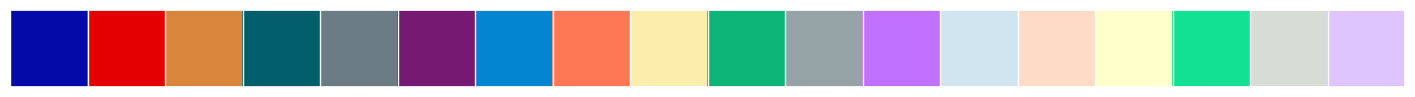

In [60]:
palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", 
            "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe", 
            "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#dfc5fe", 
          ]
sns.palplot(sns.color_palette(palette))

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>
<table>
        <tr>                                                                                   
             <th style='padding:15px;color:#030aa7;font-size:150%;text-align: left;font-weight: bold;font-family: Georgia, serif'>data.csv</th>
             <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/breast_cancer_logo.png" width="128"></th>
        </tr>  
<table>   
<table>
        <tr>                                                                                   
             <th  style="text-align:left;background-color:#053061;color:white;"> </th>
             <th  style="text-align:left;background-color:#053061;color:white;">Colonne initiale </th>
             <th  style="text-align:left;background-color:#053061;color:white;">Description</th>
        </tr>    
    <tr>
        <th  style="text-align:left"> </th>                            
        <th  style="text-align:left;font-style: italic">ID number</th> 
        <th  style="text-align:left;font-style: italic">index</th>
    </tr>    
    <tr>
        <th  style="text-align:left">0 </th>                            
        <th  style="text-align:left;color:red;font-style: italic">Diagnosis</th> 
        <th  style="text-align:left;color:red;font-style: italic">M = malignant, B = benign</th>
    </tr>    
    <tr>
        <th  style="text-align:left">1 </th>                            
        <th  style="text-align:left">radius </th>                            
        <th  style="text-align:left"></th>
    </tr>    
    <tr>
        <th  style="text-align:left">2 </th>                            
        <th  style="text-align:left">texture </th>                          
        <th  style="text-align:left">standard deviation of gray-scale values</th>
    </tr>    
    <tr>
        <th  style="text-align:left">3 </th>                            
        <th  style="text-align:left">perimeter </th>                         
        <th  style="text-align:left"></th>
    </tr>    
    <tr>
        <th  style="text-align:left">4 </th>                            
        <th  style="text-align:left">area</th>                               
        <th  style="text-align:left"></th>
    </tr> 
    <tr>
        <th  style="text-align:left">5 </th>                            
        <th  style="text-align:left">smoothness </th>                            
        <th  style="text-align:left">local variation in radius lengths</th>
    </tr>  
    <tr>
        <th  style="text-align:left">6 </th>                            
        <th  style="text-align:left">compactness </th>                      
        <th  style="text-align:left">$\frac{perimeter^2}{area - 1.0}$</th>
    </tr>    
    <tr>
        <th  style="text-align:left">7 </th>                            
        <th  style="text-align:left">concavity </th>              
        <th  style="text-align:left">severity of concave portions of the contour</th>
    </tr>  
    <tr>
        <th  style="text-align:left">8 </th>                            
        <th  style="text-align:left">concave points </th>                            
        <th  style="text-align:left">number of concave portions of the contour</th>
    </tr>   
    <tr>
        <th  style="text-align:left">9 </th>                            
        <th  style="text-align:left">symmetry </th>                           
        <th  style="text-align:left"></th>
    </tr> 
    <tr>
        <th  style="text-align:left">10 </th>                            
        <th  style="text-align:left">fractal dimension </th>                 
        <th  style="text-align:left">"coastline approximation" - 1</th>
    </tr>    
</table>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'>La moyenne, l’écart type et la « pire valeur » ou la plus grande (moyenne des trois valeurs les plus grandes) de ces variables ont été calculées pour chaque image, ce qui a donné lieu à 30 variables.</div>

In [61]:
donnees = pd.read_csv('../donnees/Breast Cancer Wisconsin (Diagnostic)/data.csv', index_col='id').drop(columns='Unnamed: 32')
donnees.sort_index(axis=1, inplace=True)
dictDiagnosis,dictRDiagnosis,dictLabels = {'M':1,'B':0},{1:'M',0:'B'},{1:'malignant',0:'benign'}

cible = 'diagnosis'

In [62]:
donnees.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
842517,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
84300903,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
84348301,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
84358402,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Structuration des données</div></b>
<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'>Les données sont structurées dans un tableau ou matrice à n lignes et p colonnes. Chacune des n lignes représente un individu et chacune des p colonnes une variable. Pour une analyse en composantes principales, la variables sont uniquement quantitatives : la matrice est donc constituée de valeurs numériques.</div> <img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/acp_representation_variables.png" width="512">

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Corrélation Pearson des variables initiales</div></b>

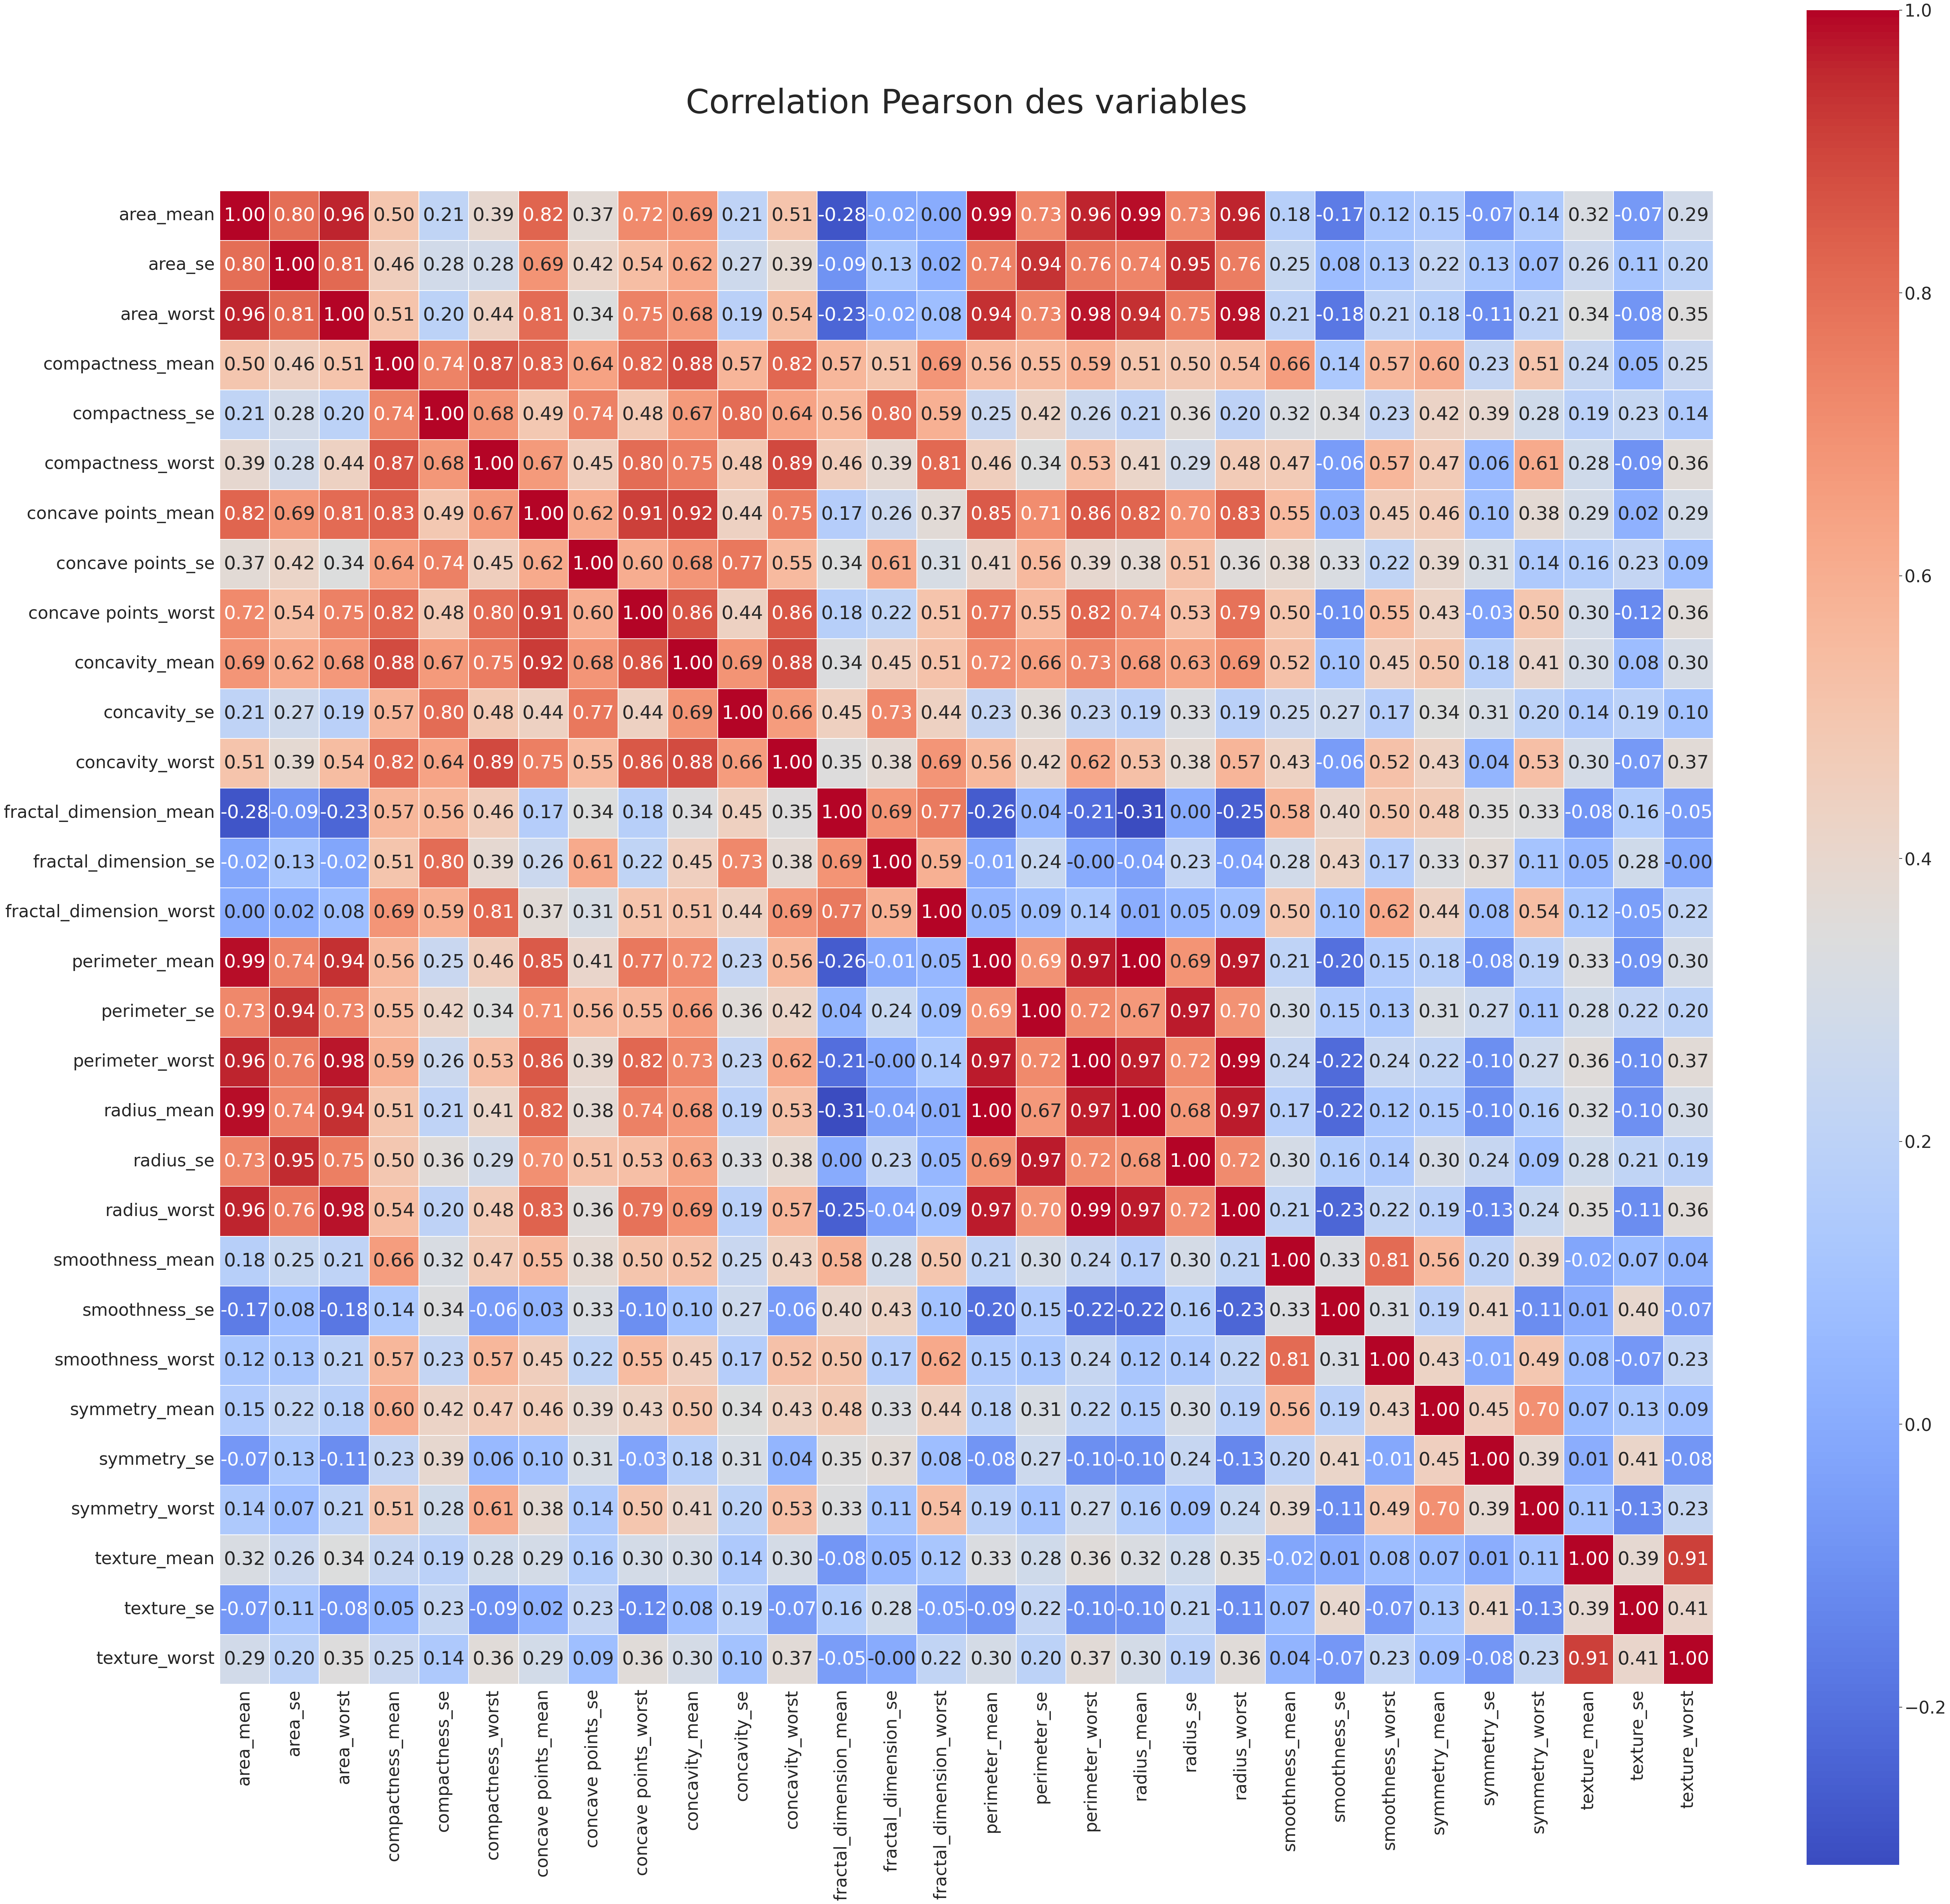

In [63]:
plt.figure(figsize=(64,64))
sns.set(font_scale=3)
plt.title('Correlation Pearson des variables', y=1.05, size=64)
sns.heatmap(donnees.drop(columns='diagnosis').corr(),linewidths=0.3,vmax=1.0, fmt= '.2f', 
            square=True, cmap='coolwarm', linecolor='white', annot=True)
sauvegarderImage('Correlation Pearson des variables initiales')
sns.set(font_scale=2)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Centrage et réduction des données</div></b>
<table>
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/moyenne.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/ecart_type.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/centrage_reduction.png"></th>
</tr>
</table>

In [64]:
modelStd = StandardScaler()
modelStd.fit(donnees.drop(columns='diagnosis'))

donnees[donnees.drop(columns='diagnosis').columns] = modelStd.transform(donnees.drop(columns='diagnosis'))
donnees.drop(columns='diagnosis').head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,0.984375,2.487578,2.001237,3.283515,1.316862,2.616665,2.532475,0.660820,2.296076,2.652874,...,1.886690,1.568466,-0.214002,1.307686,2.217515,1.148757,2.750622,-2.073335,-0.565265,-1.359293
842517,1.908708,0.742402,1.890489,-0.487072,-0.692926,-0.430444,0.548144,0.260162,1.087084,-0.023846,...,1.805927,-0.826962,-0.605351,-0.375612,0.001392,-0.805450,-0.243890,-0.353632,-0.876244,-0.369203
84300903,1.558884,1.181336,1.456285,1.052926,0.814974,1.082932,2.037231,1.424827,1.955000,1.363478,...,1.511870,0.942210,-0.297005,0.527407,0.939685,0.237036,1.152255,0.456187,-0.780083,-0.023974
84348301,-0.764464,-0.288378,-0.550021,3.402909,2.744280,3.893397,1.451707,1.115007,2.175786,1.915897,...,-0.281464,3.283553,0.689702,3.394275,2.867383,4.732680,6.046041,0.253732,-0.110409,0.133984
84358402,1.826229,1.190357,1.220724,0.539340,-0.048520,-0.313395,1.428493,1.144205,0.729259,1.371011,...,1.298575,0.280372,1.483067,0.220556,-0.009560,-0.361092,-0.868353,-1.151816,-0.790244,-1.466770


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Analyse en composantes principales</div></b>

<table>
<tr>
<th><div style='padding:15px;color:#030aa7;font-size:120%;text-align: center;font-family: Georgia, serif'>Quelle est la meilleure représentation simplifiée ?</div></th>
<th><div style='padding:15px;color:#030aa7;font-size:120%;text-align: center;font-family: Georgia, serif'>Recherche du meilleur axe de projection</div></th>
</tr>    
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/acp_analogie_photo.png" width="512"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/acp_projection_axe.png" width="512"></th>
</tr>
</table>    
<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left;font-family: Georgia, serif'>A l'évidence, c'est la vue de profil. La raison est que l'image projetée du chameau dans ce plan est plus proche de l'image initiale dans le sens ou la variance des points servant à sa représentation est plus grande et donc restitue mieux la variance des points d'origine.</div>
<table>
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/axe_variance_max.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/max_dist.png"></th>
</tr>
</table>

In [65]:
modelPCA = PCA(svd_solver='full')
modelPCA.fit(donnees.drop(columns='diagnosis'))

PCA(svd_solver='full')

In [66]:
modelPCA.explained_variance_ratio_.cumsum()*100

array([ 44.27202561,  63.24320765,  72.63637091,  79.23850582,
        84.73427432,  88.75879636,  91.00953007,  92.59825387,
        93.98790324,  95.15688143,  96.13660042,  97.00713832,
        97.81166331,  98.33502905,  98.64881227,  98.91502161,
        99.1130184 ,  99.28841435,  99.45333965,  99.55720433,
        99.65711397,  99.74857865,  99.82971477,  99.88989813,
        99.94150237,  99.96876117,  99.99176271,  99.99706051,
        99.99955652, 100.        ])

In [67]:
modelPCA.explained_variance_*100

array([1.33049908e+03, 5.70137460e+02, 2.82291016e+02, 1.98412752e+02,
       1.65163324e+02, 1.20948224e+02, 6.76408882e+01, 4.77456255e+01,
       4.17628782e+01, 3.51310875e+01, 2.94433153e+01, 2.61621161e+01,
       2.41782421e+01, 1.57286149e+01, 9.43006956e+00, 8.00034045e+00,
       5.95036135e+00, 5.27114222e+00, 4.95647002e+00, 3.12142606e+00,
       3.00256631e+00, 2.74877113e+00, 2.43836914e+00, 1.80867940e+00,
       1.55085271e+00, 8.19203712e-01, 6.91261258e-01, 1.59213600e-01,
       7.50121413e-02, 1.33279057e-02])

In [68]:
modelPCA.n_components_

30

In [69]:
inertie = pd.DataFrame(modelPCA.explained_variance_ratio_,columns=['Inertie']) 
inertie['Label'] = np.round(modelPCA.explained_variance_ratio_.cumsum()*100,2)
inertie['Dimension'] = range(1,len(modelPCA.explained_variance_)+1)
inertie['Inertie'] = np.round(inertie['Inertie']*100,2)
dim = modelPCA.n_components_
inertie = inertie[inertie['Dimension']<= dim]

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Choix du nombre des dimensions</div></b>
<div style='color:#030aa7;font-size:120%;text-align: left'>La qualité globale est mesurée par la part d'inertie expliquée. La valeur est choisie de sorte que cette part d'inertie expliquée soit supérieure à une valeur seuil fixée a priori par l'utilisateur.<br>C'est souvent le seul critère employé.<br><b>min 75%</b><br><br><b>95%</b></div>

In [70]:
sum(modelPCA.explained_variance_ratio_.cumsum()*100 <= 95) + 1

10

In [71]:
inertie[inertie.Dimension <= 10]

,Inertie,Label,Dimension
0,44.27,44.27,1
1,18.97,63.24,2
2,9.39,72.64,3
3,6.60,79.24,4
4,5.50,84.73,5
5,4.02,88.76,6
6,2.25,91.01,7
7,1.59,92.60,8
8,1.39,93.99,9
9,1.17,95.16,10


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Pourcentage d'inertie(variance) associée à chaque dimension</div></b>

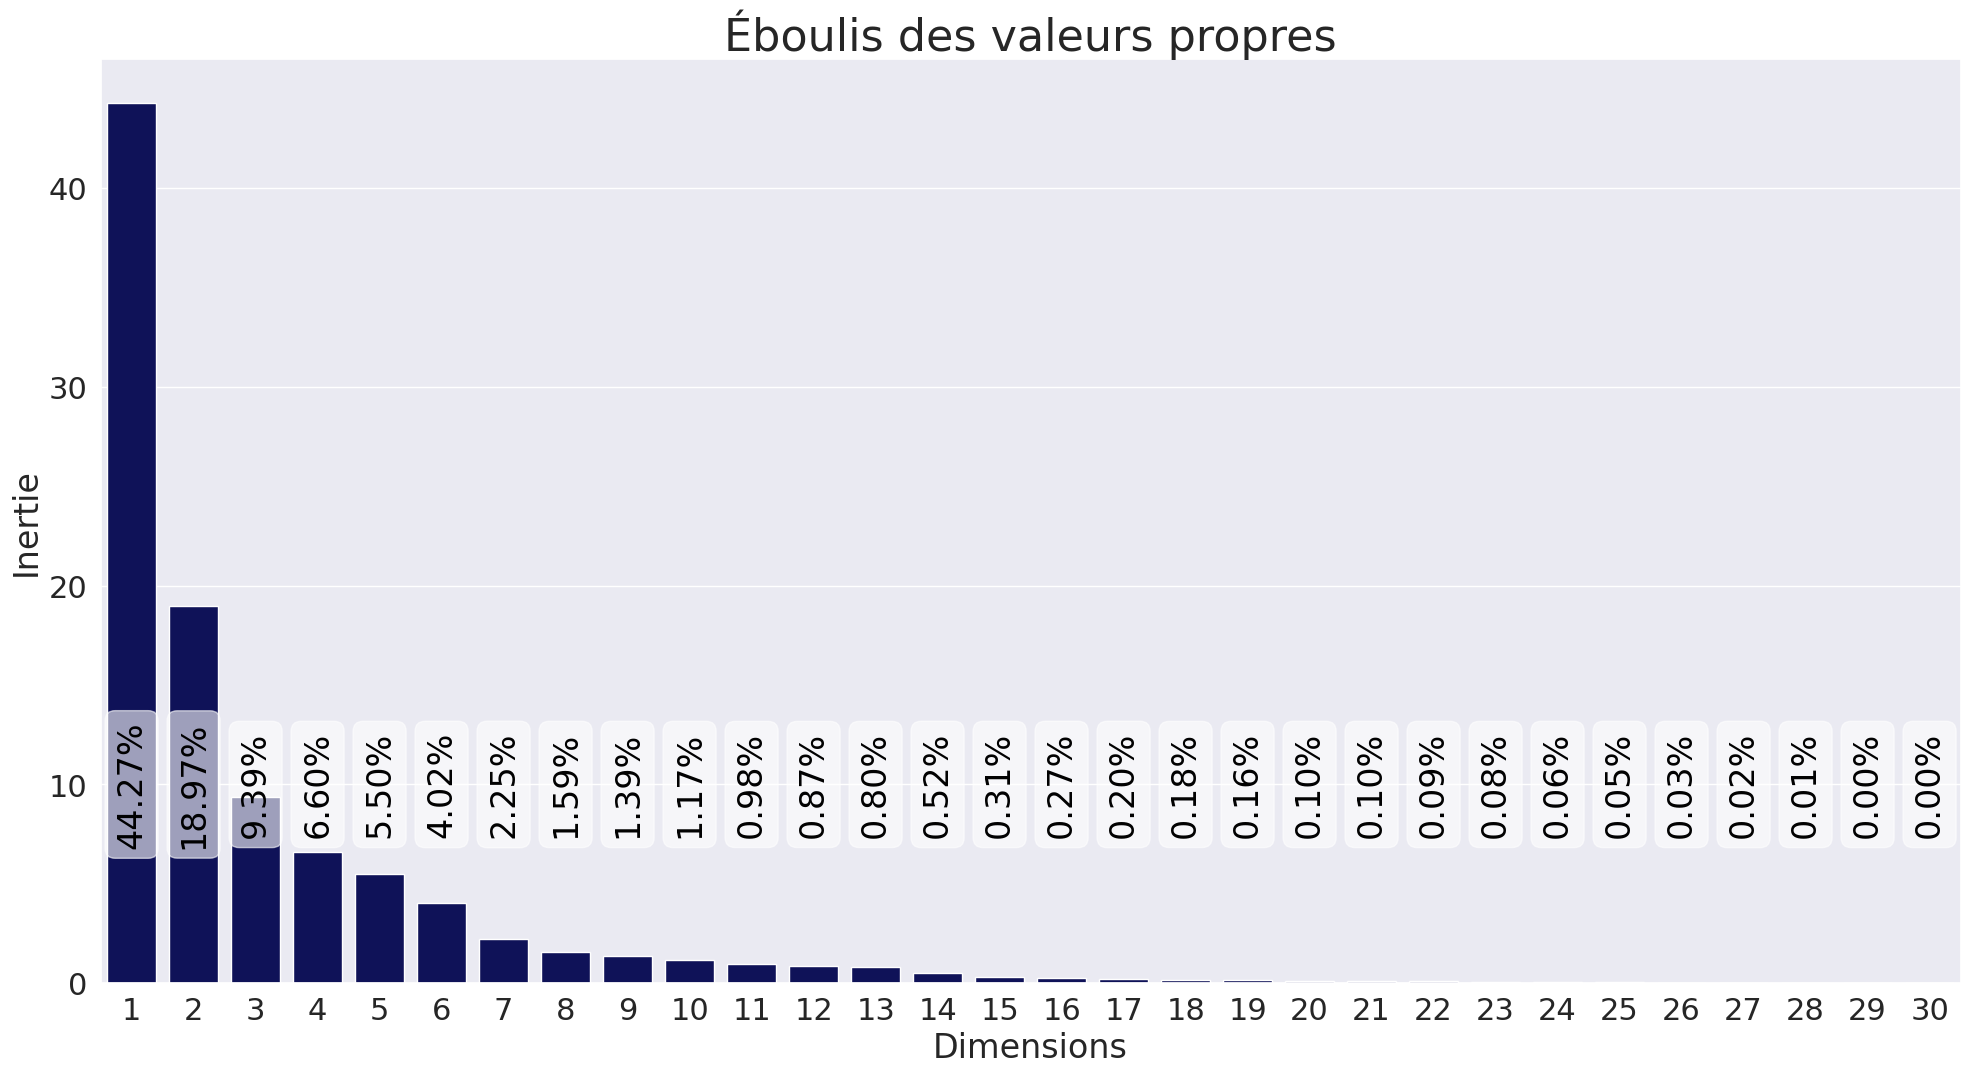

In [72]:
fig, ax = plt.subplots(figsize=(24,12));

graph = sns.barplot(x="Dimension",y='Inertie', data=inertie, color="#030764", ax=ax)

for i,nom in enumerate(inertie.sort_values('Inertie', ascending=False).Inertie):
    graph.text(
                i ,
                10,
                f'{nom:0.2f}%',
                color='black',
                rotation='vertical',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='center',
               )

ax.set_xlabel('Dimensions');
ax.set_ylabel('Inertie');
ax.set_title('Éboulis des valeurs propres', fontproperties=fm.FontProperties(size=32))
sauvegarderImage('Choix du nombre des dimensions01')

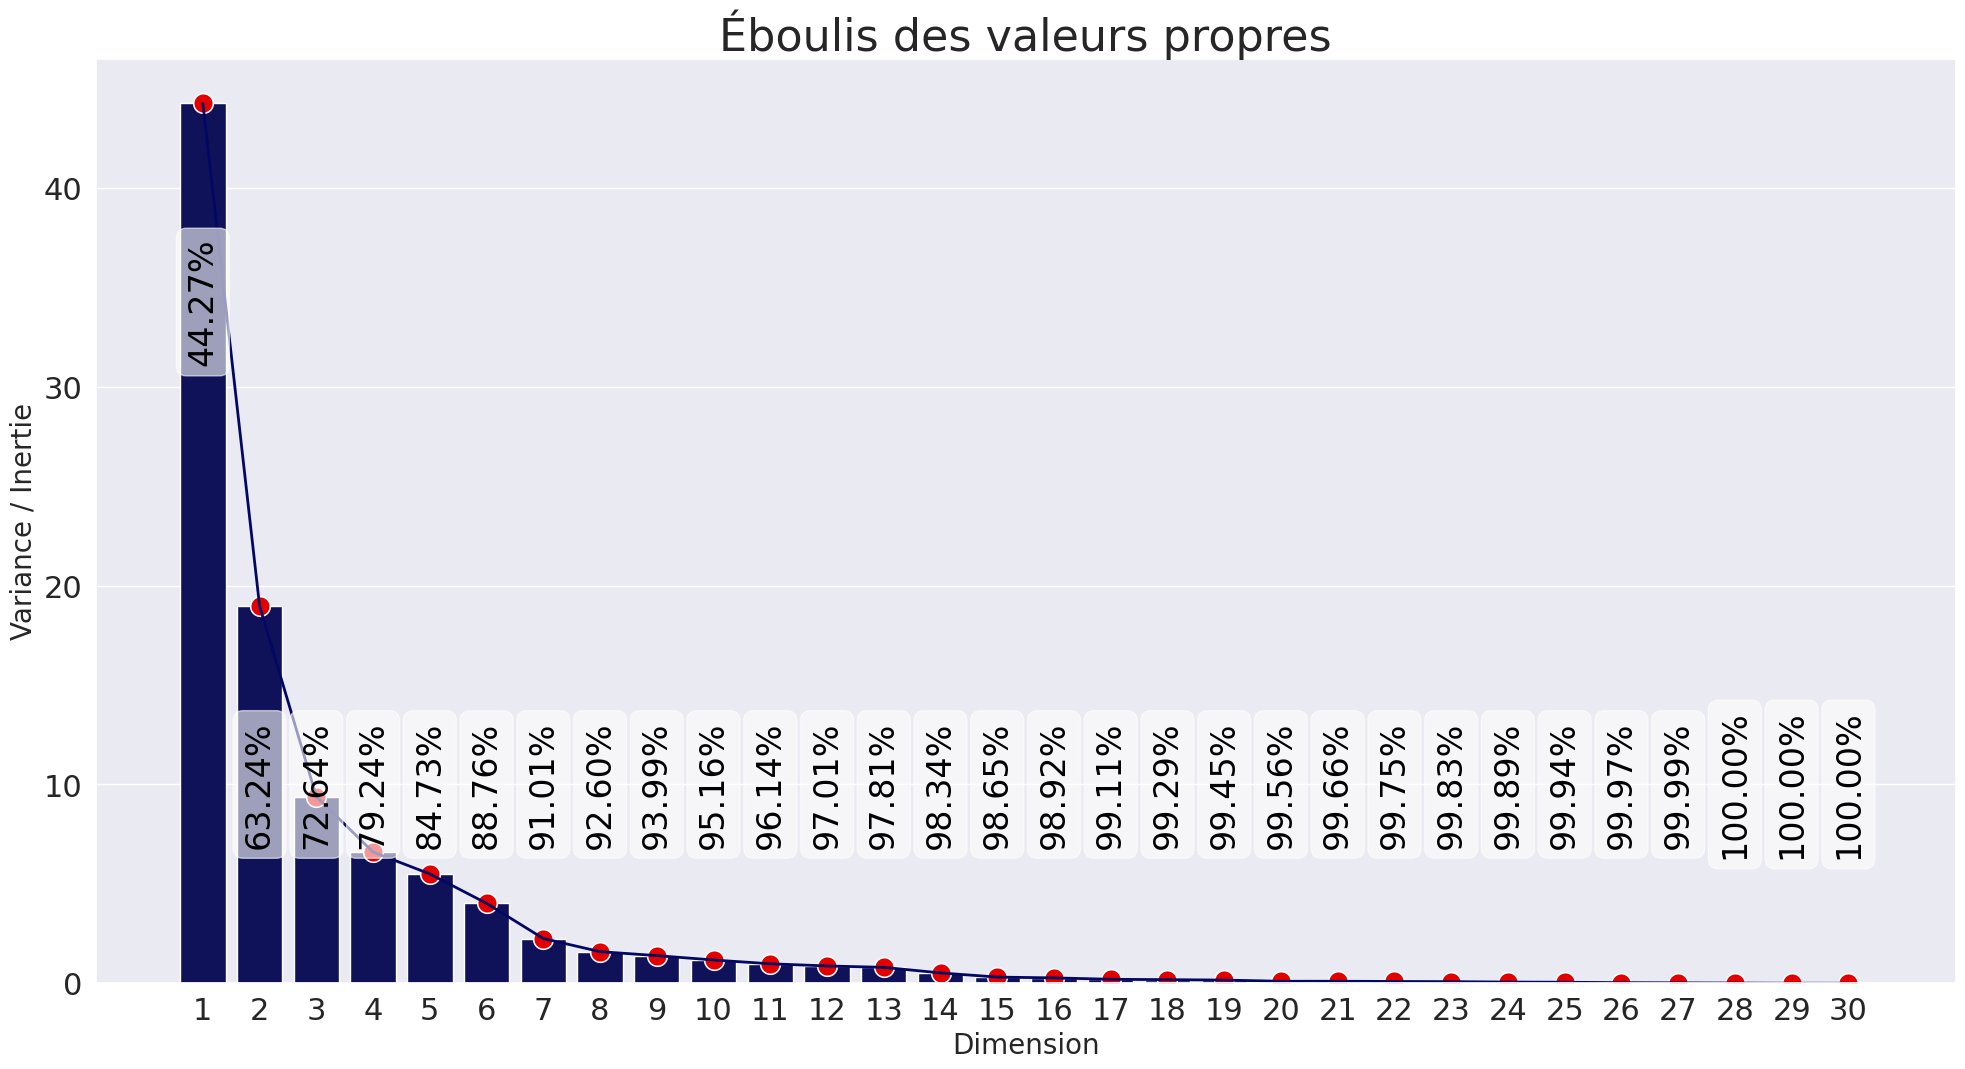

In [73]:
fig, ax = plt.subplots(figsize=(24,12));
graph = sns.barplot(x="Dimension",y='Inertie', data=inertie, color="#030764", ax=ax)

for i,(nom,valeur) in enumerate(zip(inertie.sort_values('Dimension').Label,inertie.sort_values('Dimension').Inertie)):
    # valeur = 0.1 if valeur - 0.1 < 0.1 else valeur - 0.1
    valeur = 10 if valeur - 10 < 10 else valeur - 10
    delta =  i 
    graph.text(
                delta ,
                valeur,
                f'{nom:0.2f}%',
                color='black',
                rotation='vertical',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='center',
               )
    
graph = sns.lineplot( x=inertie.Dimension - 1,
                      y='Inertie',
                      data=inertie,
                      estimator = None, 
                      lw        = 2, 
                      ci        = None,
                      color     = "#030764",
                      ax    = ax);

sns.scatterplot(x=inertie.Dimension - 1,
                y     = 'Inertie',
                data  = inertie,
                s     = 200,
                # ci    = None, 
                color = "#e50000",
                ax    = ax);    
    
ax.set_xlabel('Dimension', fontproperties=font1)
ax.set_ylabel('Variance / Inertie', fontproperties=font1)
ax.set_title('Éboulis des valeurs propres', fontproperties=fm.FontProperties(size=32))

sauvegarderImage('Choix du nombre des dimensions02')
sns.set(font_scale=2)

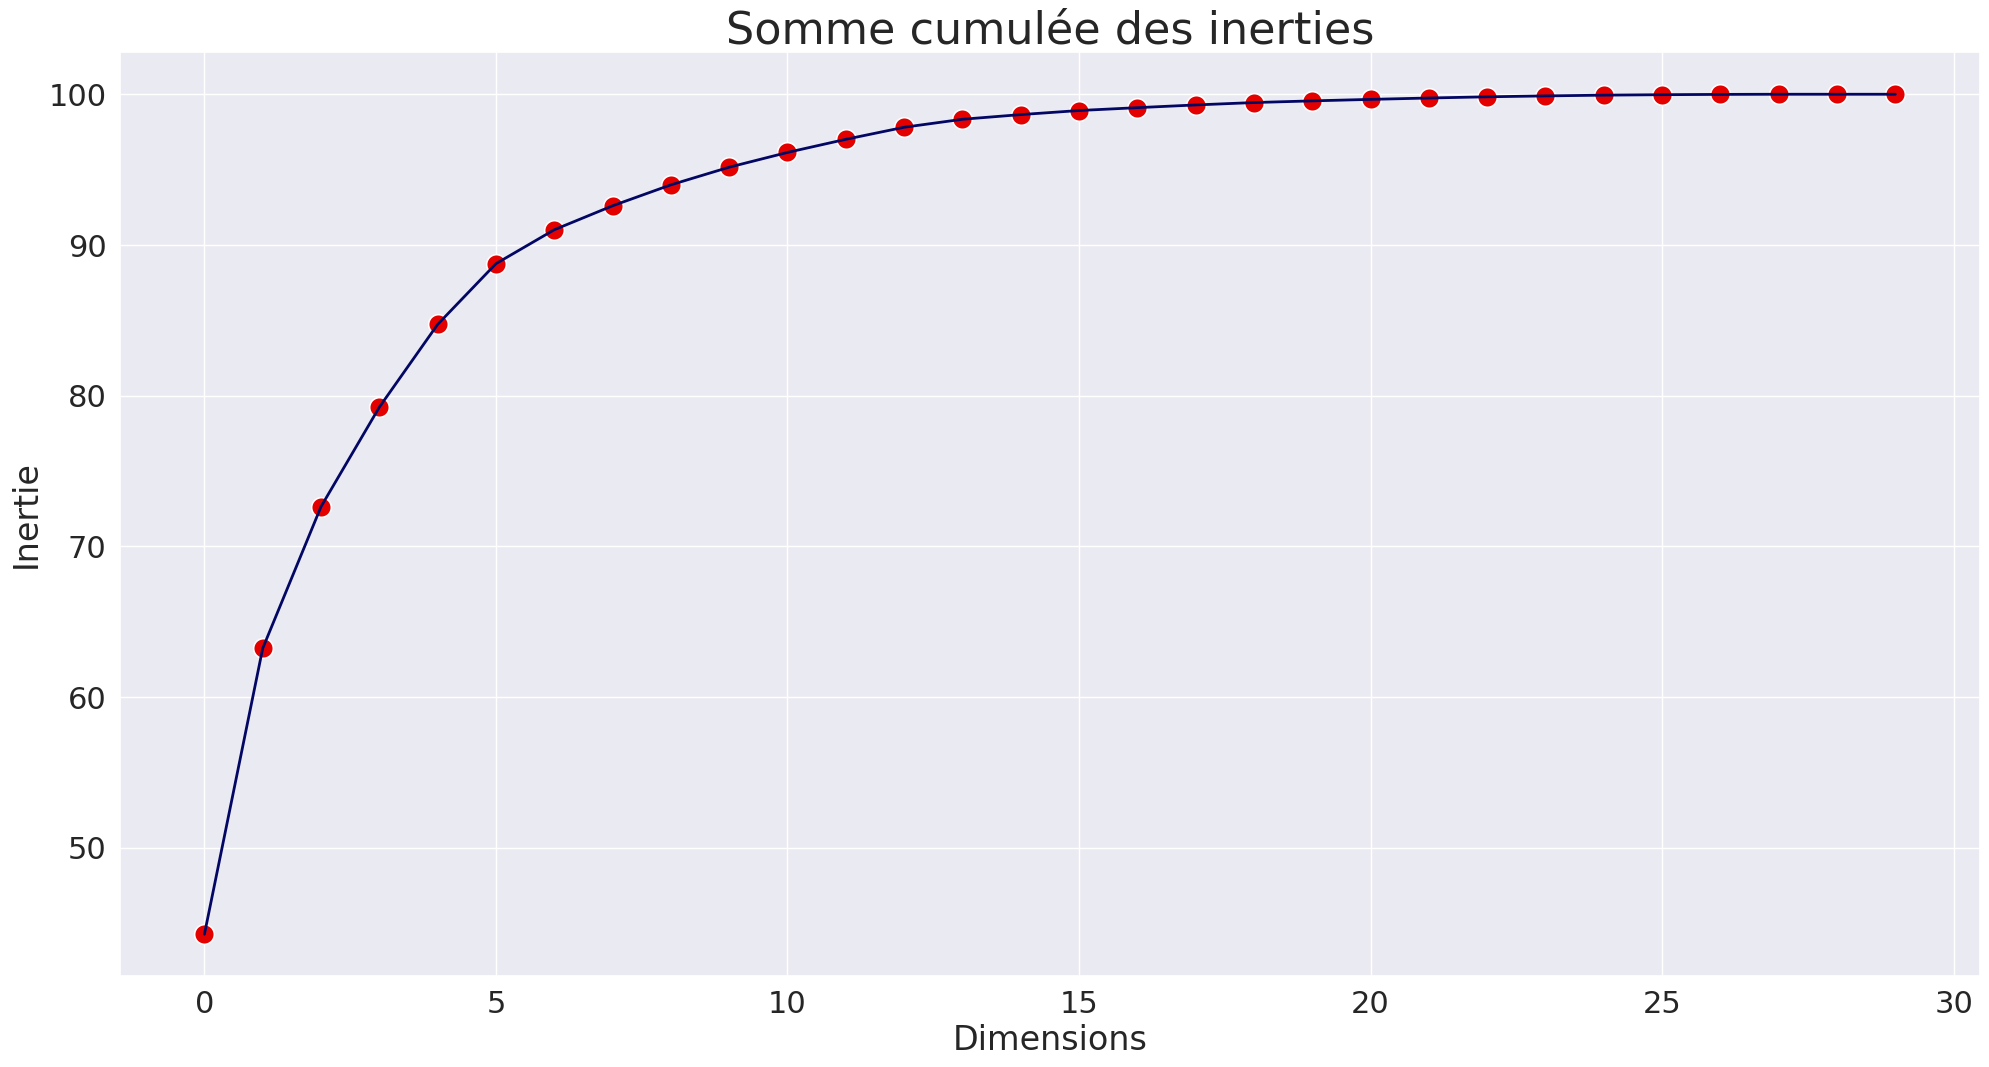

In [74]:
fig, ax = plt.subplots(figsize=(24,12));

sns.lineplot(x         = inertie.Dimension-1,
             y         = 'Label',
             data      = inertie,
             estimator = None, 
             lw        = 2, 
             color     = "#030764",
             ax        = ax);
sns.scatterplot(x     = inertie.Dimension-1,
                y     = 'Label',
                data  = inertie,
                s     = 200,
                color = "#e50000",
                ax    = ax);

ax.set_xlabel('Dimensions');
ax.set_ylabel('Inertie');
ax.set_title('Somme cumulée des inerties', fontproperties=fm.FontProperties(size=32));
sauvegarderImage('Choix du nombre des dimensions03')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Règle de Kaiser</div></b>

<div style='color:#030aa7;font-size:120%;text-align: left'>On ne conserve que les valeurs propres supérieures à leur moyenne car les autres représentent moins de variabilité qu'une seule variable initiale.</div>

In [75]:
print(f'{100 / modelPCA.n_components_}')

3.3333333333333335


In [76]:
inertie[inertie.Inertie >= (100 / modelPCA.n_components_)]

,Inertie,Label,Dimension
0,44.27,44.27,1
1,18.97,63.24,2
2,9.39,72.64,3
3,6.60,79.24,4
4,5.50,84.73,5
5,4.02,88.76,6


In [77]:
n_components,_ = inertie[inertie.Inertie >= (100 / modelPCA.n_components_)].shape

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Transformation des données</div></b>

In [78]:
modelPCA = PCA(n_components=n_components).set_output(transform="pandas")
donneesACP = modelPCA.fit_transform((donnees.drop(columns='diagnosis')))
donneesACP.columns = [f'Dimension{i:02d}' for i in range(1,n_components+1)]

<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left;font-family: Georgia, serif'>Les nouvelles dimensions doivent être indépendantes deux à deux</div>

In [79]:
donneesACP.corr().style.format("{:0.1e}").background_gradient(cmap=plt.get_cmap('Blues'),axis=0)

,Dimension01,Dimension02,Dimension03,Dimension04,Dimension05,Dimension06
Dimension01,1.0e+00,-4.0e-16,3.9e-17,-7.3e-17,1.2e-16,1.1e-16
Dimension02,-4.0e-16,1.0e+00,-5.0e-17,1.1e-16,-5.1e-17,8.5e-17
Dimension03,3.9e-17,-5.0e-17,1.0e+00,-6.7e-16,7.5e-17,1.0e-16
Dimension04,-7.3e-17,1.1e-16,-6.7e-16,1.0e+00,-2.2e-18,-1.0e-16
Dimension05,1.2e-16,-5.1e-17,7.5e-17,-2.2e-18,1.0e+00,-4.3e-17
Dimension06,1.1e-16,8.5e-17,1.0e-16,-1.0e-16,-4.3e-17,1.0e+00


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Représentation des individus</div></b>

In [80]:
(donneesACP.Dimension04 - donneesACP.Dimension04.min())

id
842302      1.560539
842517      4.076006
84300903    4.282187
84348301    5.041723
84358402    2.253631
              ...   
926424      4.016956
926682      7.700298
926954      7.283497
927241      7.550301
92751       7.493427
Name: Dimension04, Length: 569, dtype: float64

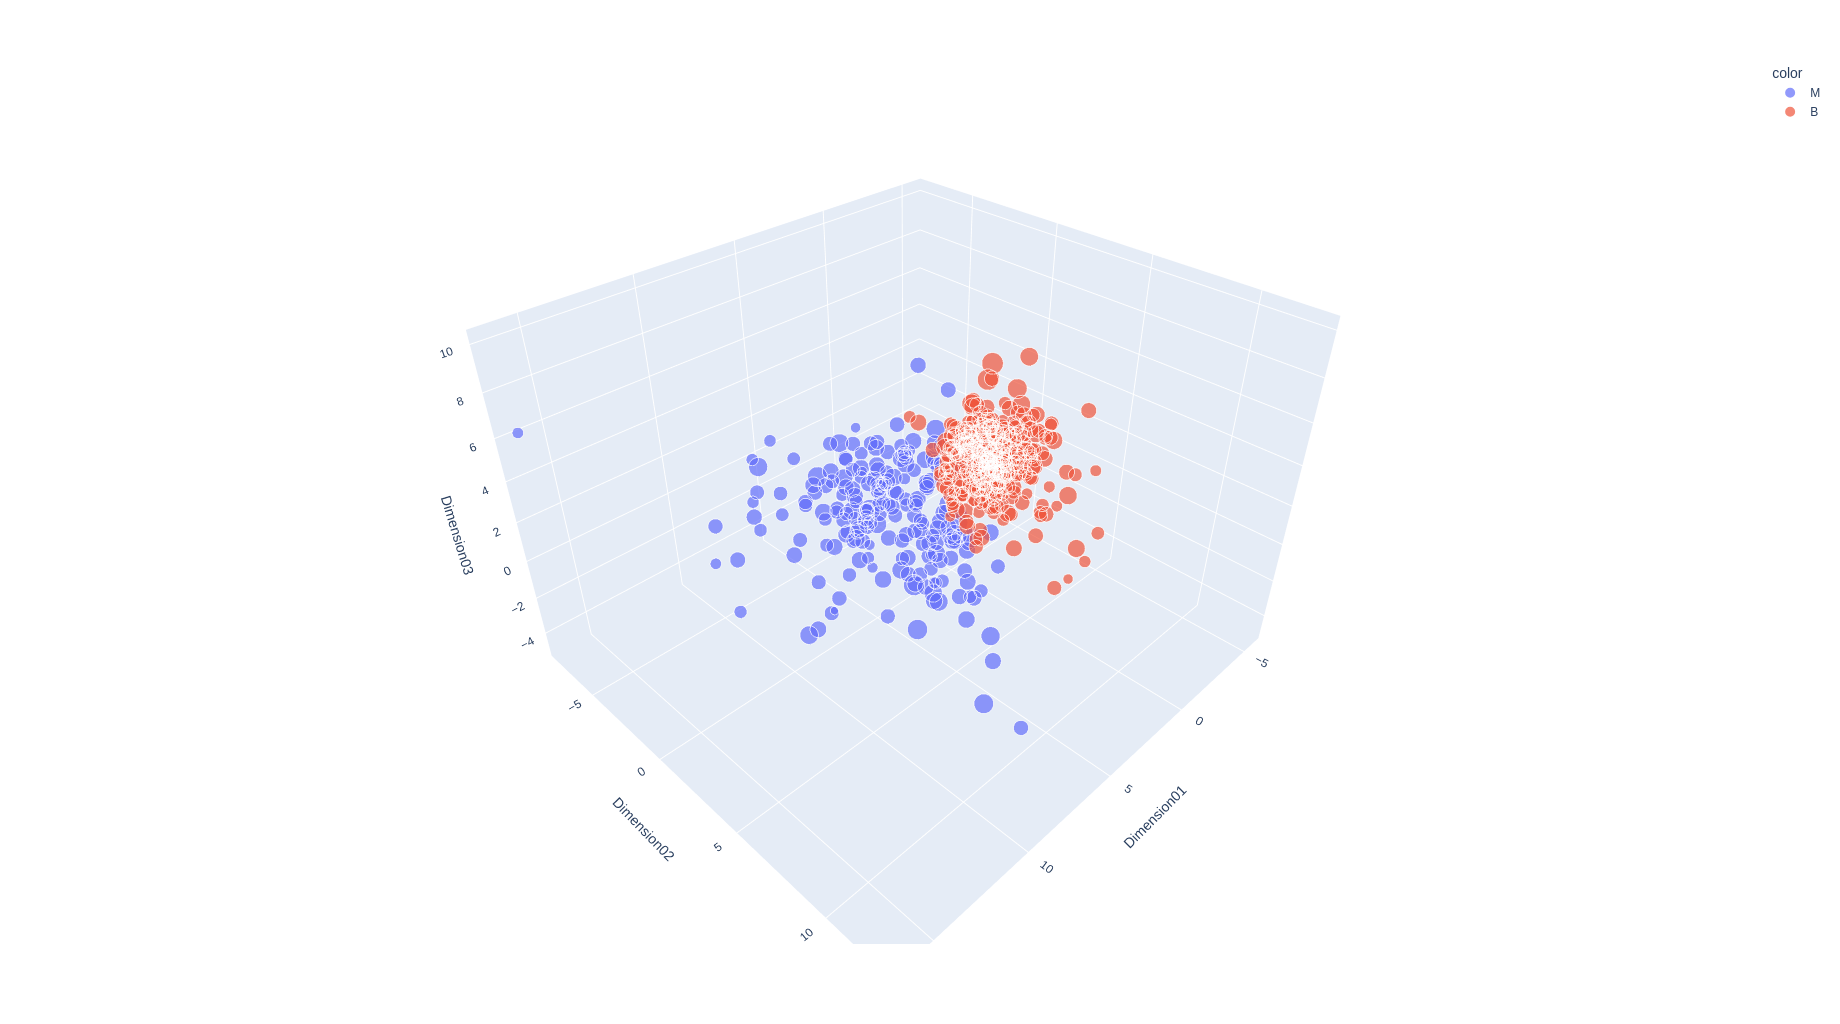

In [81]:
layout = go.Layout({"showlegend": False})

fig = px.scatter_3d(donneesACP.reset_index(), 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color=donnees.diagnosis,
                    size=(donneesACP.Dimension04 - donneesACP.Dimension04.min()),
                    # symbol='Dimension04',
                    # text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>ACP sur les valeurs moyennes et les plus grandes</div></b>

In [82]:
colonnees = donnees.filter(regex='(mean|worst)$', axis=1).columns

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Analyse en composantes principales</div></b>

<table>
<tr>
<th><div style='padding:15px;color:#030aa7;font-size:120%;text-align: center;font-family: Georgia, serif'>Quelle est la meilleure représentation simplifiée ?</div></th>
<th><div style='padding:15px;color:#030aa7;font-size:120%;text-align: center;font-family: Georgia, serif'>Recherche du meilleur axe de projection</div></th>
</tr>    
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/acp_analogie_photo.png" width="512"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/acp_projection_axe.png" width="512"></th>
</tr>
</table>    
<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left;font-family: Georgia, serif'>A l'évidence, c'est la vue de profil. La raison est que l'image projetée du chameau dans ce plan est plus proche de l'image initiale dans le sens ou la variance des points servant à sa représentation est plus grande et donc restitue mieux la variance des points d'origine.</div>
<table>
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/axe_variance_max.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/max_dist.png"></th>
</tr>
</table>

In [83]:
modelPCA = PCA(svd_solver='full')
modelPCA.fit(donnees[colonnees])

PCA(svd_solver='full')

In [84]:
modelPCA.explained_variance_ratio_.cumsum()*100

array([ 53.40353208,  75.02492532,  83.51514111,  87.92568418,
        92.09541927,  95.13637184,  96.54065578,  97.30784742,
        97.99843919,  98.48672354,  98.89052624,  99.25475655,
        99.53965659,  99.73521117,  99.85369479,  99.92169774,
        99.97167979,  99.99248059,  99.99922631, 100.        ])

In [85]:
modelPCA.explained_variance_*100

array([1.06995105e+03, 4.33189182e+02, 1.70103267e+02, 8.83661623e+01,
       8.35415234e+01, 6.09261272e+01, 2.81351254e+01, 1.53708465e+01,
       1.38361521e+01, 9.78288009e+00, 8.09027239e+00, 7.29743130e+00,
       5.70803253e+00, 3.91797735e+00, 2.37384417e+00, 1.36245361e+00,
       1.00140097e+00, 4.16748402e-01, 1.35151866e-01, 1.55010369e-02])

In [86]:
modelPCA.n_components_

20

In [87]:
inertie = pd.DataFrame(modelPCA.explained_variance_ratio_,columns=['Inertie']) 
inertie['Label'] = np.round(modelPCA.explained_variance_ratio_.cumsum()*100,2)
inertie['Dimension'] = range(1,len(modelPCA.explained_variance_)+1)
inertie['Inertie'] = np.round(inertie['Inertie']*100,2)
dim = modelPCA.n_components_
inertie = inertie[inertie['Dimension']<= dim]

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Choix du nombre des dimensions</div></b>
<div style='color:#030aa7;font-size:120%;text-align: left'>La qualité globale est mesurée par la part d'inertie expliquée. La valeur est choisie de sorte que cette part d'inertie expliquée soit supérieure à une valeur seuil fixée a priori par l'utilisateur.<br>C'est souvent le seul critère employé.<br><b>min 75%</b><br><br><b>95%</b></div>

In [88]:
sum(modelPCA.explained_variance_ratio_.cumsum()*100 <= 95) + 1

6

In [89]:
inertie[inertie.Dimension <= 10]

,Inertie,Label,Dimension
0,53.40,53.40,1
1,21.62,75.02,2
2,8.49,83.52,3
3,4.41,87.93,4
4,4.17,92.10,5
5,3.04,95.14,6
6,1.40,96.54,7
7,0.77,97.31,8
8,0.69,98.00,9
9,0.49,98.49,10


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Pourcentage d'inertie(variance) associée à chaque dimension</div></b>

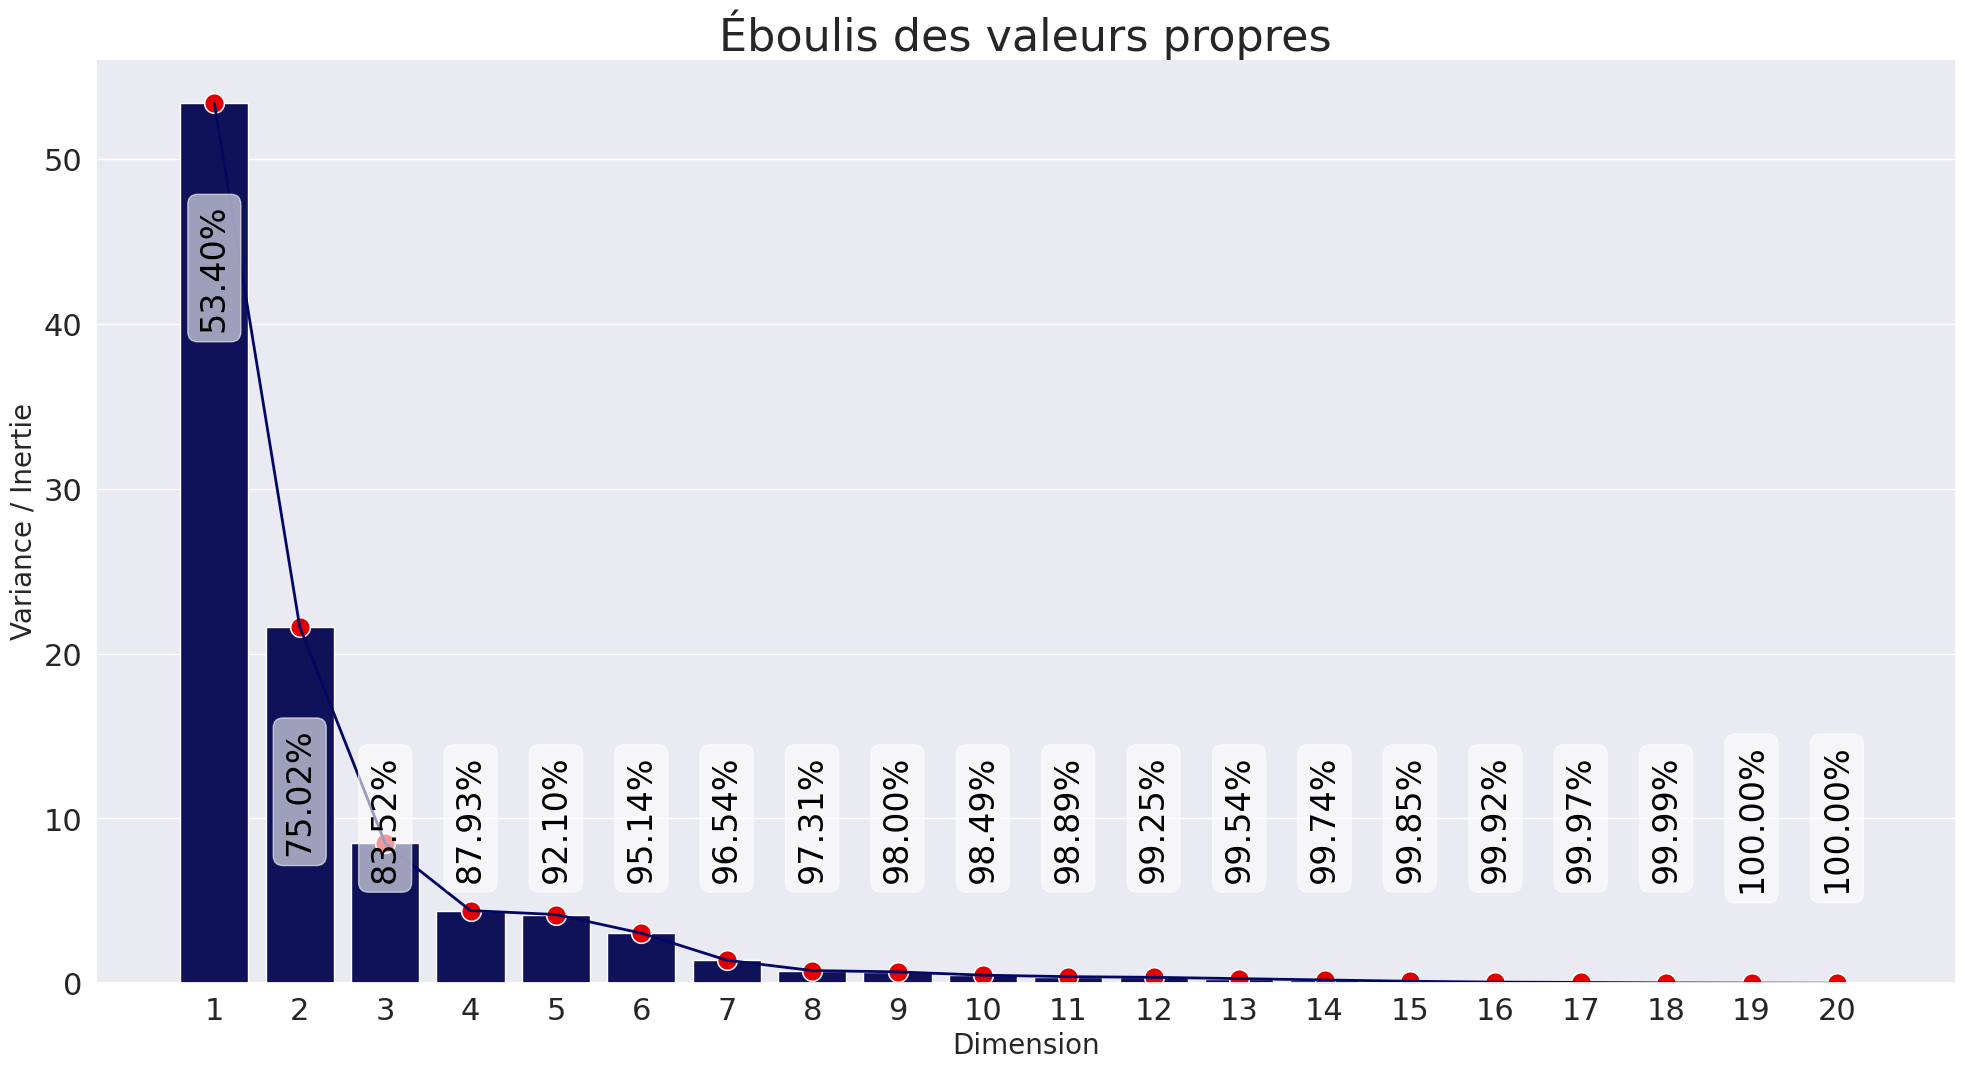

In [90]:
fig, ax = plt.subplots(figsize=(24,12));
graph = sns.barplot(x="Dimension",y='Inertie', data=inertie, color="#030764", ax=ax)

for i,(nom,valeur) in enumerate(zip(inertie.sort_values('Dimension').Label,inertie.sort_values('Dimension').Inertie)):
    # valeur = 0.1 if valeur - 0.1 < 0.1 else valeur - 0.1
    valeur = 10 if valeur - 10 < 10 else valeur - 10
    delta =  i 
    graph.text(
                delta ,
                valeur,
                f'{nom:0.2f}%',
                color='black',
                rotation='vertical',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='center',
               )
    
graph = sns.lineplot( x=inertie.Dimension - 1,
                      y='Inertie',
                      data=inertie,
                      estimator = None, 
                      lw        = 2, 
                      ci        = None,
                      color     = "#030764",
                      ax    = ax);

sns.scatterplot(x=inertie.Dimension - 1,
                y     = 'Inertie',
                data  = inertie,
                s     = 200,
                # ci    = None, 
                color = "#e50000",
                ax    = ax);    
    
ax.set_xlabel('Dimension', fontproperties=font1)
ax.set_ylabel('Variance / Inertie', fontproperties=font1)
ax.set_title('Éboulis des valeurs propres', fontproperties=fm.FontProperties(size=32))

sauvegarderImage('Choix du nombre des dimensions02')
sns.set(font_scale=2)

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Règle de Kaiser</div></b>

<div style='color:#030aa7;font-size:120%;text-align: left'>On ne conserve que les valeurs propres supérieures à leur moyenne car les autres représentent moins de variabilité qu'une seule variable initiale.</div>

In [91]:
print(f'{100 / modelPCA.n_components_}')

5.0


In [92]:
inertie[inertie.Inertie >= (100 / modelPCA.n_components_)]

,Inertie,Label,Dimension
0,53.40,53.40,1
1,21.62,75.02,2
2,8.49,83.52,3


In [93]:
n_components,_ = inertie[inertie.Inertie >= (100 / modelPCA.n_components_)].shape
n_components

3

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Transformation des données</div></b>

In [94]:
modelPCA = PCA(n_components=n_components).set_output(transform="pandas")
donneesACP = modelPCA.fit_transform((donnees.drop(columns='diagnosis')))
donneesACP.columns = [f'Dimension{i:02d}' for i in range(1,n_components+1)]
donneesACP['diagnosis'] = donnees.diagnosis

<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left;font-family: Georgia, serif'>Les nouvelles dimensions doivent être indépendantes deux à deux</div>

In [95]:
donneesACP.drop(columns=cible).corr().style.format("{:0.1e}").background_gradient(cmap=plt.get_cmap('Blues'),axis=0)

,Dimension01,Dimension02,Dimension03
Dimension01,1.0e+00,-4.0e-16,4.0e-17
Dimension02,-4.0e-16,1.0e+00,-5.0e-17
Dimension03,4.0e-17,-5.0e-17,1.0e+00


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Représentation des individus</div></b>

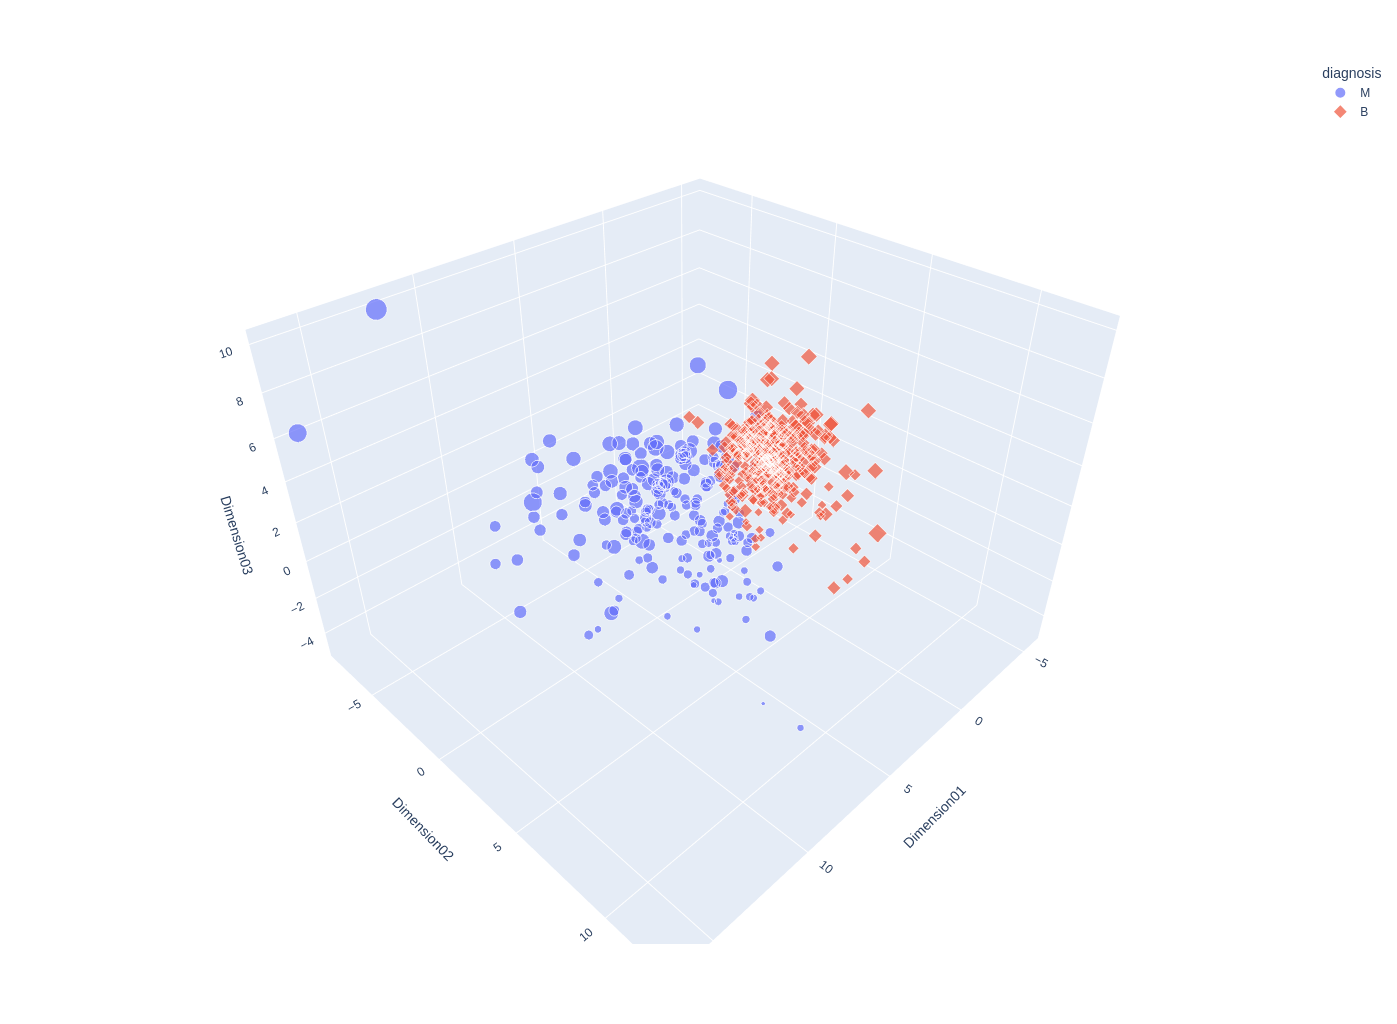

In [96]:
layout = go.Layout({"showlegend": False})
affichage = donneesACP #[donneesACP.Dimension01 < 250]
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='diagnosis',
                    size=(affichage.Dimension03 - affichage.Dimension03.min()),
                    symbol='diagnosis',
                    # text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>ACP sur les valeurs moyennes et les plus grandes</div></b>

In [41]:
colonnees = donnees.filter(regex='(worst)$', axis=1).columns

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Analyse en composantes principales</div></b>

<table>
<tr>
<th><div style='padding:15px;color:#030aa7;font-size:120%;text-align: center;font-family: Georgia, serif'>Quelle est la meilleure représentation simplifiée ?</div></th>
<th><div style='padding:15px;color:#030aa7;font-size:120%;text-align: center;font-family: Georgia, serif'>Recherche du meilleur axe de projection</div></th>
</tr>    
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/acp_analogie_photo.png" width="512"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/acp_projection_axe.png" width="512"></th>
</tr>
</table>    
<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left;font-family: Georgia, serif'>A l'évidence, c'est la vue de profil. La raison est que l'image projetée du chameau dans ce plan est plus proche de l'image initiale dans le sens ou la variance des points servant à sa représentation est plus grande et donc restitue mieux la variance des points d'origine.</div>
<table>
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/axe_variance_max.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/max_dist.png"></th>
</tr>
</table>

In [42]:
modelPCA = PCA(svd_solver='full')
modelPCA.fit(donnees[colonnees])

PCA(svd_solver='full')

In [43]:
modelPCA.explained_variance_ratio_.cumsum()*100

array([ 56.97236619,  77.83218935,  85.85986426,  91.2667279 ,
        96.41346056,  98.25065261,  99.08928395,  99.80762997,
        99.95997544, 100.        ])

In [44]:
modelPCA.explained_variance_*100

array([5.70726696e+02, 2.08965482e+02, 8.04180814e+01, 5.41638277e+01,
       5.15579381e+01, 1.84042655e+01, 8.40107796e+00, 7.19610717e+00,
       1.52613689e+00, 4.00950223e-01])

In [45]:
modelPCA.n_components_

10

In [46]:
inertie = pd.DataFrame(modelPCA.explained_variance_ratio_,columns=['Inertie']) 
inertie['Label'] = np.round(modelPCA.explained_variance_ratio_.cumsum()*100,2)
inertie['Dimension'] = range(1,len(modelPCA.explained_variance_)+1)
inertie['Inertie'] = np.round(inertie['Inertie']*100,2)
dim = modelPCA.n_components_
inertie = inertie[inertie['Dimension']<= dim]

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Choix du nombre des dimensions</div></b>
<div style='color:#030aa7;font-size:120%;text-align: left'>La qualité globale est mesurée par la part d'inertie expliquée. La valeur est choisie de sorte que cette part d'inertie expliquée soit supérieure à une valeur seuil fixée a priori par l'utilisateur.<br>C'est souvent le seul critère employé.<br><b>min 75%</b><br><br><b>95%</b></div>

In [47]:
sum(modelPCA.explained_variance_ratio_.cumsum()*100 <= 95) + 1

5

In [48]:
inertie[inertie.Dimension <= 10]

,Inertie,Label,Dimension
0,56.97,56.97,1
1,20.86,77.83,2
2,8.03,85.86,3
3,5.41,91.27,4
4,5.15,96.41,5
5,1.84,98.25,6
6,0.84,99.09,7
7,0.72,99.81,8
8,0.15,99.96,9
9,0.04,100.00,10


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Pourcentage d'inertie(variance) associée à chaque dimension</div></b>

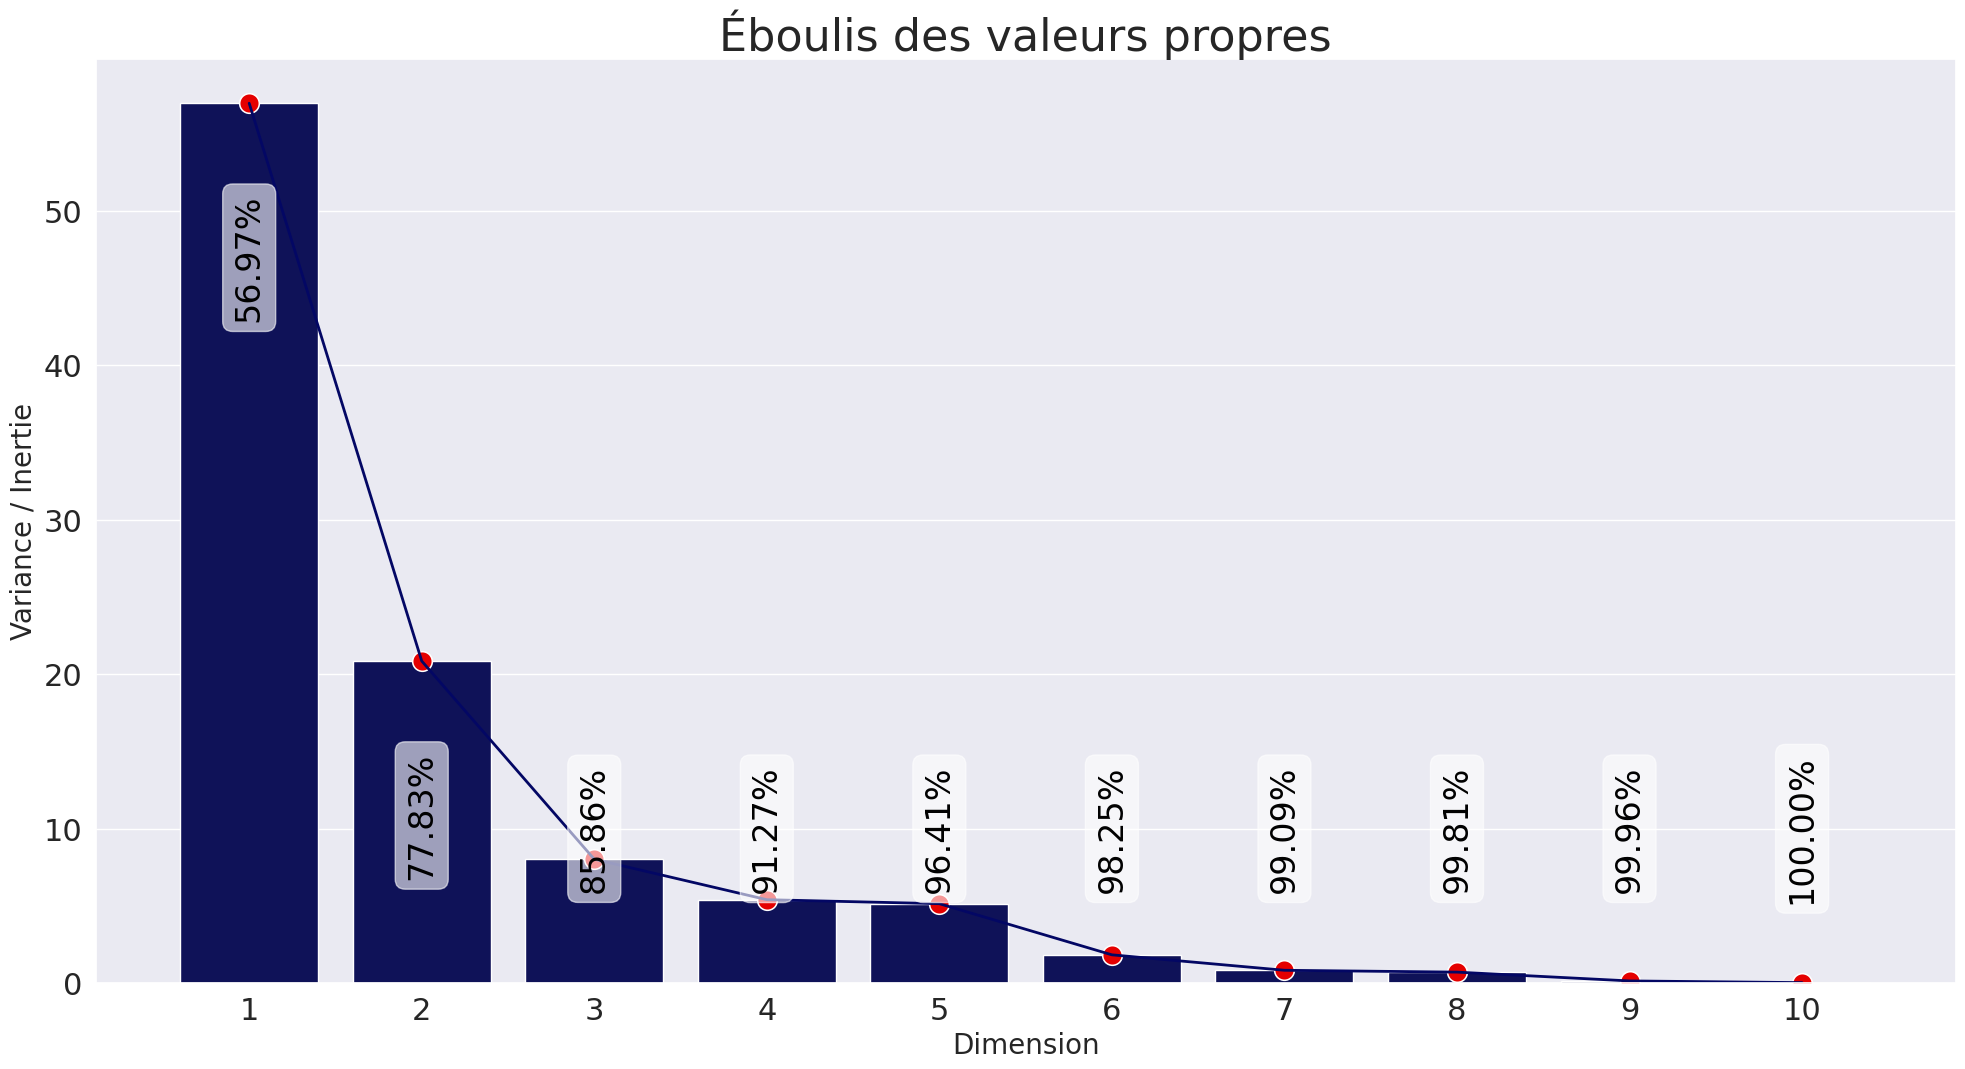

In [49]:
fig, ax = plt.subplots(figsize=(24,12));
graph = sns.barplot(x="Dimension",y='Inertie', data=inertie, color="#030764", ax=ax)

for i,(nom,valeur) in enumerate(zip(inertie.sort_values('Dimension').Label,inertie.sort_values('Dimension').Inertie)):
    # valeur = 0.1 if valeur - 0.1 < 0.1 else valeur - 0.1
    valeur = 10 if valeur - 10 < 10 else valeur - 10
    delta =  i 
    graph.text(
                delta ,
                valeur,
                f'{nom:0.2f}%',
                color='black',
                rotation='vertical',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='center',
               )
    
graph = sns.lineplot( x=inertie.Dimension - 1,
                      y='Inertie',
                      data=inertie,
                      estimator = None, 
                      lw        = 2, 
                      ci        = None,
                      color     = "#030764",
                      ax    = ax);

sns.scatterplot(x=inertie.Dimension - 1,
                y     = 'Inertie',
                data  = inertie,
                s     = 200,
                # ci    = None, 
                color = "#e50000",
                ax    = ax);    
    
ax.set_xlabel('Dimension', fontproperties=font1)
ax.set_ylabel('Variance / Inertie', fontproperties=font1)
ax.set_title('Éboulis des valeurs propres', fontproperties=fm.FontProperties(size=32))

sauvegarderImage('Choix du nombre des dimensions02')
sns.set(font_scale=2)

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Règle de Kaiser</div></b>

<div style='color:#030aa7;font-size:120%;text-align: left'>On ne conserve que les valeurs propres supérieures à leur moyenne car les autres représentent moins de variabilité qu'une seule variable initiale.</div>

In [50]:
print(f'{100 / modelPCA.n_components_}')

10.0


In [51]:
inertie[inertie.Inertie >= (100 / modelPCA.n_components_)]

,Inertie,Label,Dimension
0,56.97,56.97,1
1,20.86,77.83,2


In [52]:
n_components,_ = inertie[inertie.Inertie >= (100 / modelPCA.n_components_)].shape
n_components

2

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Transformation des données</div></b>

In [53]:
n_components = 3

In [54]:
modelPCA = PCA(n_components=n_components).set_output(transform="pandas")
donneesACP = modelPCA.fit_transform((donnees.drop(columns='diagnosis')))
donneesACP.columns = [f'Dimension{i:02d}' for i in range(1,n_components+1)]
donneesACP['diagnosis'] = donnees.diagnosis

<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left;font-family: Georgia, serif'>Les nouvelles dimensions doivent être indépendantes deux à deux</div>

In [55]:
donneesACP.drop(columns=cible).corr().style.format("{:0.1e}").background_gradient(cmap=plt.get_cmap('Blues'),axis=0)

,Dimension01,Dimension02,Dimension03
Dimension01,1.0e+00,-4.0e-16,4.0e-17
Dimension02,-4.0e-16,1.0e+00,-5.0e-17
Dimension03,4.0e-17,-5.0e-17,1.0e+00


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Représentation des individus</div></b>

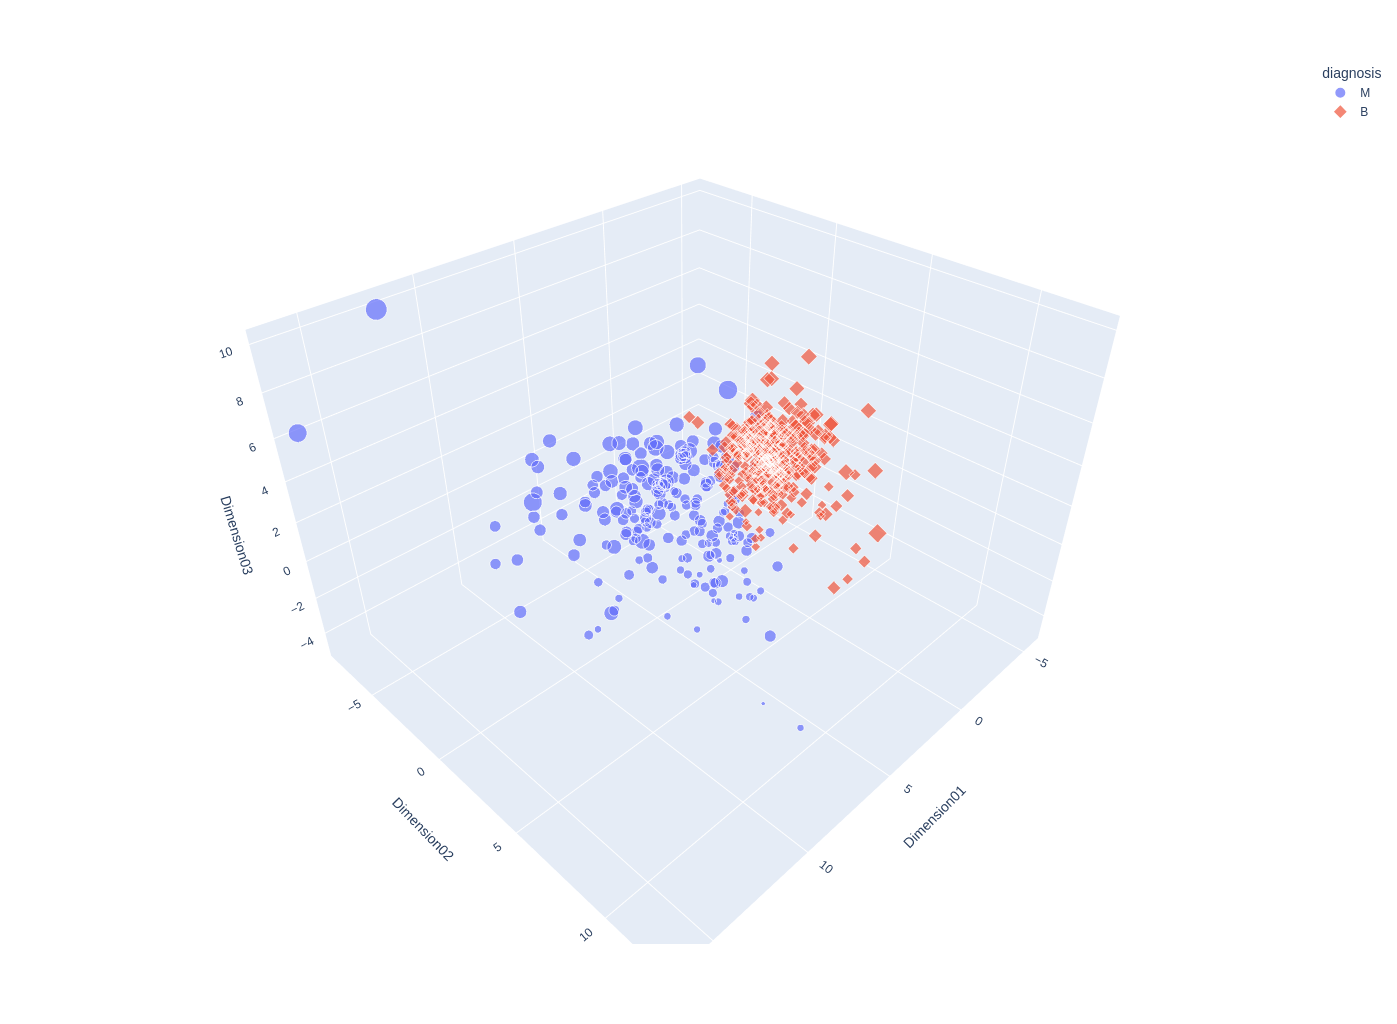

In [56]:
layout = go.Layout({"showlegend": False})
affichage = donneesACP #[donneesACP.Dimension01 < 250]
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='diagnosis',
                    size=(affichage.Dimension03 - affichage.Dimension03.min()),
                    symbol='diagnosis',
                    # text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()